In [1]:
import sys
#sys.path.append('/home/artemybombastic/MyGit/KD_Summer_Work/Segmentation')
sys.path.append('/home/artemybombastic/MyGit/KD_Summer_Work')
from Segmentation.Loop import Train_model
from Transformation.Model import Transfered_Resnet50
from Segmentation.Model import Unet
from torchvision.transforms.functional import adjust_sharpness,adjust_contrast,to_pil_image,pil_to_tensor
import yaml
from PIL import Image
import cv2
from torch.nn import functional as F
#from Batching import img2batch,batch2img,img4batch,batch4img
from torch.optim import AdamW
from torch.nn import BCELoss
import torch
from torch import nn
import torch.utils.data as data_utils
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import numpy as np

In [2]:
def cut_boot_from_photo(img,mask):
    sig=nn.Sigmoid()
    real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2) 
    return real_mask

In [3]:
def cut_boot_from_photo(img,mask):
    sig=nn.Sigmoid()
    real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2) 
    new_img=real_mask.float()*img
    non_mask = (sig(mask)<(sig(mask).max()+sig(mask).min())/2).float()
    new_img+=non_mask    
    dilated_mask=dilate(real_mask,R=50)
    dilated_background=(dilated_mask<0.5).float()*img
    dilated_around_background=(dilated_mask.float()-real_mask.float())*img
    dilated_around_non_background=(dilated_mask.float()-real_mask.float())*new_img
    mn_mx=0.5
    koef=1.0
    new_shadow=koef*((dilated_around_background<mn_mx).float()*dilated_around_background)
    new_img_with_shadow=new_img-koef*((dilated_around_background<mn_mx).float()*dilated_around_non_background)+koef*((dilated_around_background<mn_mx).float()*dilated_around_background)
    boot_with_shadow_mask=real_mask+(((dilated_around_background<mn_mx).float()*dilated_around_background)>0).float()
    
    return new_img_with_shadow,boot_with_shadow_mask

In [4]:
def dilate(mask,R=20):
    kernel_size=2*R +1
    dilitation_kernel=torch.ones(1,1,kernel_size,kernel_size)
    new_mask=F.conv2d(mask.float(),dilitation_kernel,padding=R)
    new_mask=new_mask>0
    return new_mask

In [5]:
option_path=fr'/home/artemybombastic/MyGit/KD_Summer_Work/config.yml'
device='cuda' if torch.cuda.is_available() else 'cpu'
device='cpu'
print(device)
with open(option_path,'r') as file_option:
    option=yaml.safe_load(file_option)



cpu


In [6]:
from torch.utils.data import Dataset
import os
from torchvision import transforms
class Transform_Dataset(Dataset):
    def __init__(self,img_path,transformation=None):
        super(Transform_Dataset,self).__init__()
        self.transformation=transformation
        self.all_items=[os.path.join(img_path,img) for img in os.listdir(img_path)]
        self.all_items.sort()

        if self.transformation==None:
            self.transformation=transforms.Compose([
            transforms.Resize((1024,512)),
            transforms.ToTensor()
            ])
    def __len__(self):
        return len(self.all_items)
    def __getitem__(self,idx):
        img=Image.open(self.all_items[idx])
        
        exif = img._getexif()
        if exif is not None:
            orientation = exif.get(274)  
            if orientation == 3:
                img = img.rotate(180, expand=True)
            elif orientation == 6:
                img = img.rotate(270, expand=True)
            elif orientation == 8:
                img = img.rotate(90, expand=True)

        if img.width>img.height:
            img = img.rotate(90, expand=True)
        tensor_img=self.transformation(img)
        return {
            'img':tensor_img,
        }

In [7]:
trans_dataset=Transform_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData/low_boots')
trans_dataloader=DataLoader(dataset=trans_dataset,batch_size=1,drop_last=False,shuffle=True)

In [8]:
segm_model=Unet(3,64).to(device)

In [9]:
try:
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/SegmData/unet_model_{device}.pth',weights_only=True)
    segm_model.load_state_dict(weights_dict)
except:
    print('Весов нет, инициализируем новые')

In [10]:
trans_model=Transfered_Resnet50()



In [11]:
if f'degr_net_{device}.pth' in os.listdir('/home/artemybombastic/MyGit/KD_Data/'):
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/degr_net_{device}.pth',weights_only=True)
    trans_model.load_state_dict(weights_dict)
    print('yes')


yes


In [12]:
# bt=0
# for batch in trans_dataloader:
#     bt=batch
#     break

In [13]:
#pred=segm_model(bt['img'])

In [14]:
#trans_pred=trans_model(bt['img'])

In [15]:
#trans_pred[0]

In [16]:
#rotate_trans=transforms.functional.rotate(bt['img'],3,expand=False, fill=(255, 255, 255))

In [17]:
#rotate_trans.shape

In [18]:
#plt.imshow(rotate_trans[0].detach().permute(1,2,0))

In [19]:
def bb_finder(mask,img=None):
    rows=torch.any(mask>0,dim=1)
    columns=torch.any(mask>0,dim=0)
    r_min=torch.where(rows)[0][0]
    r_max=torch.where(rows)[0][-1]
    c_min=torch.where(columns)[0][0]
    c_max=torch.where(columns)[0][-1]
    #print(r_min,r_max+1,c_min,c_max+1)
    if img!=None:
        return img[:,r_min:r_max+1,c_min:c_max+1]
    return mask[r_min:r_max+1,c_min:c_max+1]

In [20]:
#new_img,mask=cut_boot_from_photo(bt['img'][0],pred[0])

In [21]:
#croped_img=bb_finder(mask[0],new_img)

In [22]:
#img_pil=to_pil_image(croped_img.float())

In [23]:
#img_pil

In [24]:
#img=correct_resize(img_pil)

In [25]:
#img

In [26]:
def correct_resize(img):
    blank_image=Image.new('RGB',size=(762,1100),color=(255,255,255))
    if img.size[0]>img.size[1]:
        correct_height=int(img.size[1]//(img.size[0]/562))
        correct_size=(562,correct_height)
        img=img.resize(correct_size)
        blank_image.paste(img,(100,1100-correct_height-100))
        
    else:
        correct_width=int(img.size[0]//(img.size[1]/820))
        correct_size=(correct_width,820)
        img=img.resize(correct_size)
        blank_image.paste(img,((762-correct_width)//2,100))
    return blank_image

In [27]:
def pipeline(dataloader,path):
    k=0

    for batch in dataloader:
        original_image=batch['img']

        #угол:
        if rotate:
            degr_pred=trans_model(original_image)
            original_image=to_pil_image(original_image[0])
            
            original_image=original_image.rotate(degr_pred[0].item(), expand=False, fillcolor=(255, 255, 255))#угол
            original_image=torch.unsqueeze(pil_to_tensor(original_image).float()/255,0)

        #сегментация
        segm_pred=segm_model(original_image)
        new_img,mask=cut_boot_from_photo(original_image[0],segm_pred[0])

        #постановка на линейку
        croped_img=bb_finder(mask[0],new_img)
        img_pil=to_pil_image(croped_img.float())
        img=correct_resize(img_pil)

        #остальное
        img.save(f'{path}/{k}',"JPEG")
        k+=1
        print(k)

In [28]:
pipeline(dataloader=trans_dataloader,path=option['Result']['img_path'],rotate=False)

1
2
3
4
5
6
7


KeyboardInterrupt: 

In [ ]:
plt.imshow((a).detach().permute(1,2,0))

In [53]:
a/255

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])

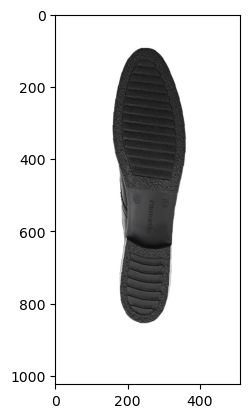

In [45]:
plt.imshow(pil_to_tensor(a).permute(1,2,0))

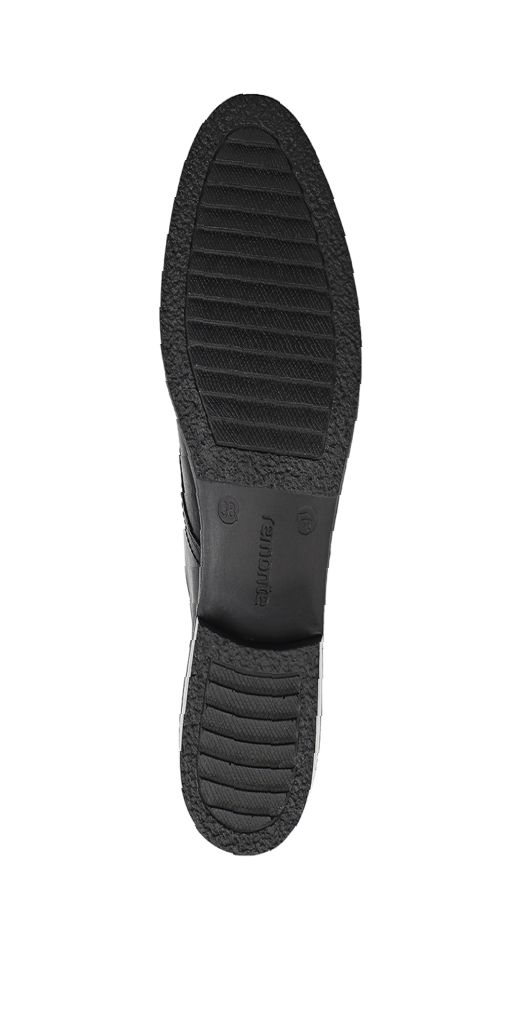

In [48]:
a

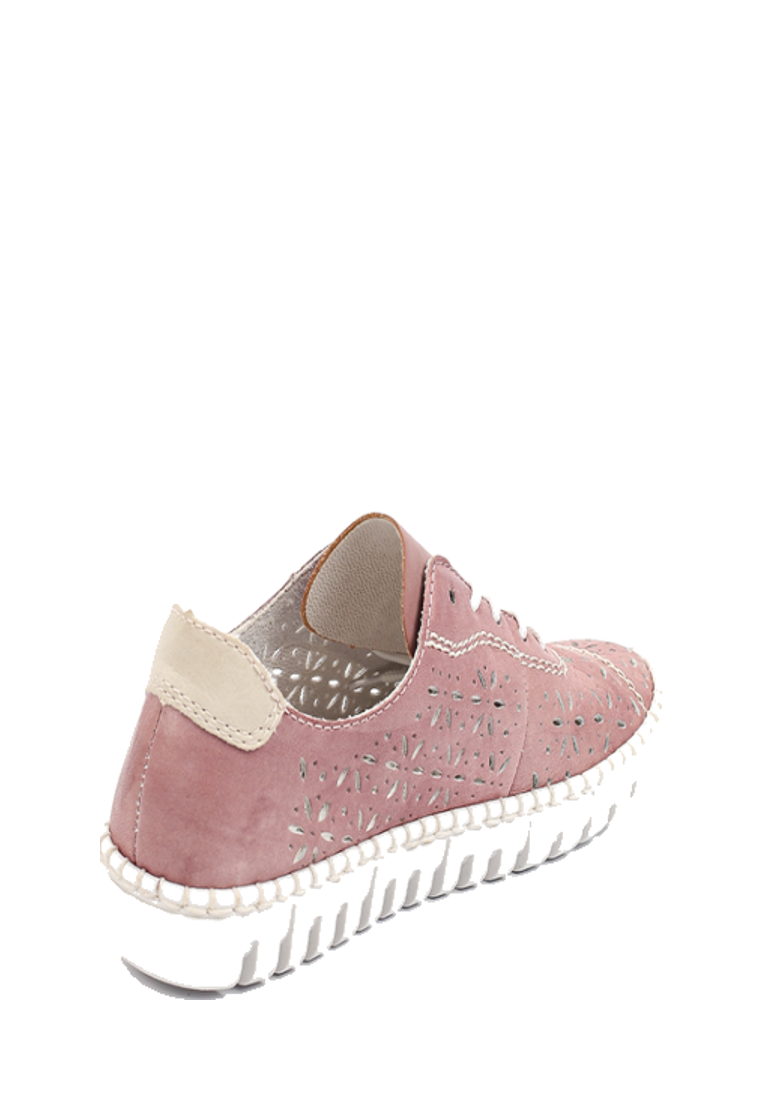

In [19]:
#img